# Diabetes Prediction — Leakage-Safe ML Pipeline

A leakage-safe machine learning workflow for the Pima diabetes dataset, focused on reproducible preprocessing, model comparison, calibrated probabilities, and validation-based threshold selection.

The notebook follows a clean supervised-learning workflow:

**EDA → leakage-safe preprocessing → model comparison → calibration → validation-selected operating threshold → final test evaluation → interpretation → exportable artifact**

## Background

The Pima diabetes dataset is a well-known benchmark for binary classification. Its compact structure makes it easy to inspect, while still supporting a complete workflow across validation, preprocessing, model comparison, calibration, and threshold selection.

Dataset: **Pima Diabetes** benchmark — 768 records for female patients aged 21 or older.  
The target is `Outcome`, where `1` indicates a diabetes-positive record and `0` indicates a diabetes-negative record.

> **Scope note:** this notebook presents a machine-learning benchmark workflow for analysis, modeling, reproducibility, and threshold selection.  
> Any real-world medical use would require separate clinical validation, governance, and approval.

**Goal:** build a reproducible ML pipeline that avoids preprocessing leakage, compares multiple models, calibrates probabilities, selects an operating threshold on validation data only, and reports the final result once on a held-out test set.

## Data Dictionary

| Feature | Description |
|---|---|
| `Pregnancies` | Number of times pregnant |
| `Glucose` | Plasma glucose concentration |
| `BloodPressure` | Diastolic blood pressure |
| `SkinThickness` | Triceps skinfold thickness |
| `Insulin` | 2-hour serum insulin |
| `BMI` | Body mass index |
| `DiabetesPedigreeFunction` | Diabetes pedigree function |
| `Age` | Age in years |
| `Outcome` | `1 = diabetes-positive`, `0 = diabetes-negative` |

## Import Libraries


In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.preprocessing import FunctionTransformer, StandardScaler

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    USE_IMBLEARN_SMOTE = True
    IMBLEARN_STATUS = "available"
except Exception as exc:

    SMOTE = None
    ImbPipeline = None
    USE_IMBLEARN_SMOTE = False
    IMBLEARN_STATUS = f"unavailable_or_incompatible: {type(exc).__name__}: {exc}"


class SafeSklearnPipeline(ClassifierMixin, BaseEstimator):
    """Minimal sklearn-compatible pipeline used only when imblearn is unavailable.

    It keeps preprocessing inside CV/calibration and supports nested clf__ params
    for RandomizedSearchCV. It does not perform SMOTE; estimator-side balancing
    is applied in make_pipeline when this fallback is used.
    """

    def __init__(self, steps):
        self.steps = steps

    @property
    def named_steps(self):
        return dict(getattr(self, "steps_", self.steps))

    def get_params(self, deep=True):
        params = {"steps": self.steps}
        if not deep:
            return params

        for name, step in self.steps:
            params[name] = step
            if hasattr(step, "get_params"):
                for key, value in step.get_params(deep=True).items():
                    params[f"{name}__{key}"] = value
        return params

    def set_params(self, **params):
        if "steps" in params:
            self.steps = params.pop("steps")

        step_lookup = dict(self.steps)
        for key, value in params.items():
            if "__" in key:
                step_name, sub_key = key.split("__", 1)
                if step_name not in step_lookup:
                    raise ValueError(f"Unknown pipeline step: {step_name}")
                step_lookup[step_name].set_params(**{sub_key: value})
            else:
                updated = False
                new_steps = []
                for name, step in self.steps:
                    if name == key:
                        new_steps.append((name, value))
                        updated = True
                    else:
                        new_steps.append((name, step))
                if not updated:
                    raise ValueError(f"Unknown pipeline parameter: {key}")
                self.steps = new_steps
                step_lookup = dict(self.steps)
        return self

    def fit(self, X, y=None, **fit_params):
        self.steps_ = [(name, clone(step)) for name, step in self.steps]
        Xt = X
        for name, step in self.steps_[:-1]:
            if hasattr(step, "fit_transform"):
                Xt = step.fit_transform(Xt, y)
            else:
                Xt = step.fit(Xt, y).transform(Xt)

        final_name, final_estimator = self.steps_[-1]
        final_estimator.fit(Xt, y, **fit_params)
        self.classes_ = getattr(final_estimator, "classes_", None)
        self.n_features_in_ = getattr(final_estimator, "n_features_in_", None)
        return self

    def _transform(self, X):
        Xt = X
        for name, step in self.steps_[:-1]:
            Xt = step.transform(Xt)
        return Xt

    def predict(self, X):
        return self.steps_[-1][1].predict(self._transform(X))

    def predict_proba(self, X):
        return self.steps_[-1][1].predict_proba(self._transform(X))


    def score(self, X, y):
        return self.steps_[-1][1].score(self._transform(X), y)

try:
    from xgboost import XGBClassifier

    HAS_XGB = True
except Exception:
    HAS_XGB = False

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams["figure.figsize"] = (8.5, 5)

# Illustrative operating costs:
# false negatives are treated as more expensive than false positives.
COST_FP = 1.0
COST_FN = 7.0
CALIBRATION_METHOD = "sigmoid"

print("Imbalance handling:", "SMOTE via imbalanced-learn" if USE_IMBLEARN_SMOTE else "class-weight fallback")
if not USE_IMBLEARN_SMOTE:
    print("imbalanced-learn status:", IMBLEARN_STATUS)


Imbalance handling: class-weight fallback
imbalanced-learn status: unavailable_or_incompatible: ModuleNotFoundError: No module named 'imblearn'


## Load Dataset


In [2]:
EXPECTED_COLUMNS = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome",
]

candidate_paths = [
    Path("/kaggle/input/pima-indians-diabetes-database/diabetes.csv"),
    Path("/kaggle/input/diabetes/diabetes.csv"),
    Path("/kaggle/input/pimaindiansdiabetescsv/diabetes.csv"),
    Path("data/raw/diabetes.csv"),
    Path("diabetes.csv"),
]


def load_diabetes_csv(paths, expected_columns=EXPECTED_COLUMNS):
    """Load the first CSV that matches the expected Pima diabetes schema."""
    expected = set(expected_columns)
    checked_paths = []

    for path in paths:
        if not path.is_file():
            continue

        checked_paths.append(str(path))
        preview = pd.read_csv(path, nrows=5)
        missing = sorted(expected - set(preview.columns))

        if missing:
            print(f"Skipped {path}: missing columns {missing}")
            continue

        candidate = pd.read_csv(path)
        extra = sorted(set(candidate.columns) - expected)
        if extra:
            print(f"Loaded {path} with extra columns ignored: {extra}")

        return candidate[expected_columns].copy(), path

    kaggle_input = Path("/kaggle/input")
    discovered_csvs = sorted(kaggle_input.rglob("*.csv")) if kaggle_input.exists() else []

    for path in discovered_csvs:
        if path in paths:
            continue

        checked_paths.append(str(path))
        preview = pd.read_csv(path, nrows=5)
        missing = sorted(expected - set(preview.columns))

        if missing:
            continue

        candidate = pd.read_csv(path)
        extra = sorted(set(candidate.columns) - expected)
        if extra:
            print(f"Loaded {path} with extra columns ignored: {extra}")

        return candidate[expected_columns].copy(), path

    raise FileNotFoundError(
        "Could not find a CSV matching the expected Pima diabetes schema. "
        "Attach the Kaggle dataset or update candidate_paths. "
        f"Checked {len(checked_paths)} CSV path(s)."
    )


df, data_path = load_diabetes_csv(candidate_paths)

print(f"Loaded: {data_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print("Schema validation: passed")

Loaded: diabetes.csv
Shape: 768 rows × 9 columns
Schema validation: passed


## Initial Data Exploration

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


In [6]:
df.shape

(768, 9)

# Data Cleaning & Preprocessing (EDA)

## Check missing values & duplicates


In [7]:
# Missing values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
# Count duplicate rows
df.duplicated().sum()

0

### No explicit nulls. Domain-invalid zero values are inspected before being handled inside the pipeline.

Some biomedical measurements cannot realistically be zero in this dataset context.  
The next table reports these zero counts before modeling; the values are later converted to `NaN` inside the preprocessing pipeline and imputed within cross-validation to avoid leakage.

## Inspect impossible zeros and define pipeline-safe handling

In [9]:
BASE_FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

ZERO_AS_MISSING_COLUMNS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_profile = (
    df[ZERO_AS_MISSING_COLUMNS]
    .eq(0)
    .sum()
    .rename("zero_count")
    .to_frame()
)
zero_profile["zero_rate"] = zero_profile["zero_count"] / len(df)
zero_profile = zero_profile.sort_values("zero_count", ascending=False)

display(zero_profile.style.format({"zero_rate": "{:.2%}"}))


def zeros_to_nan(X: pd.DataFrame) -> pd.DataFrame:
    """Replace clinically impossible zero values with NaN inside the pipeline."""
    X = X.copy()
    X[ZERO_AS_MISSING_COLUMNS] = X[ZERO_AS_MISSING_COLUMNS].replace(0, np.nan)
    return X


def add_interactions(X: pd.DataFrame) -> pd.DataFrame:
    """Add interaction features after zero handling and before imputation."""
    X = X.copy()
    X["Age_BMI"] = X["Age"] * X["BMI"]
    X["Glucose_BMI"] = X["Glucose"] * X["BMI"]
    X["Preg_Age_Ratio"] = X["Pregnancies"] / (X["Age"] + 1)
    return X


def expected_cost(y_true, proba, threshold, cost_fp=COST_FP, cost_fn=COST_FN):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * cost_fp + fn * cost_fn


def positive_rate(y):
    return float(np.mean(y))


def make_calibrated(estimator, method=CALIBRATION_METHOD, cv=5):
    """Compatibility wrapper for scikit-learn versions using estimator/base_estimator."""
    try:
        return CalibratedClassifierCV(estimator=estimator, method=method, cv=cv)
    except TypeError:
        return CalibratedClassifierCV(base_estimator=estimator, method=method, cv=cv)

,zero_count,zero_rate
Insulin,374,48.70%
SkinThickness,227,29.56%
BloodPressure,35,4.56%
BMI,11,1.43%
Glucose,5,0.65%


# Feature engineering (for EDA visuals)


In [10]:
df_vis = df.copy()
df_vis[ZERO_AS_MISSING_COLUMNS] = df_vis[ZERO_AS_MISSING_COLUMNS].replace(0, np.nan)

for col in ZERO_AS_MISSING_COLUMNS:
    df_vis[col] = df_vis[col].fillna(df_vis[col].median())

## Age Groups

In [11]:
df_vis['AgeGroup'] = pd.cut(df_vis['Age'], bins=[20,30,40,50,60,100], labels=['20s','30s','40s','50s','60s+'])

## BMI Categories

In [12]:
df_vis['BMI_Category'] = pd.cut(df_vis['BMI'], bins=[0,18.5,25,30,100], labels=['Underweight','Normal','Overweight','Obese'])

## New features

In [13]:
df_vis['Age_BMI'] = df_vis['Age'] * df_vis['BMI']
df_vis['Glucose_BMI'] = df_vis['Glucose'] * df_vis['BMI']
df_vis['Preg_Age_Ratio'] = df_vis['Pregnancies'] / (df_vis['Age'] + 1)

### Interaction-style features are used for exploratory views and mirrored safely inside the modeling pipeline.



# Exploratory Data Analysis (EDA) & Visualization

## Class Imbalance Visualization

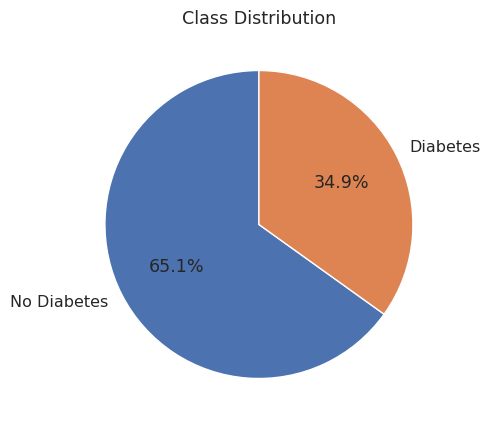

In [14]:
outcome_counts = (
    df["Outcome"]
    .map({0: "No Diabetes", 1: "Diabetes"})
    .value_counts()
    .reindex(["No Diabetes", "Diabetes"])
)

plt.figure(figsize=(5, 5))
outcome_counts.plot.pie(
    autopct="%1.1f%%",
    startangle=90,
)
plt.title("Class Distribution")
plt.ylabel("")
plt.show()

### The target distribution is moderately imbalanced, so AUPRC and threshold behavior are more informative than accuracy alone.


## Pairplot

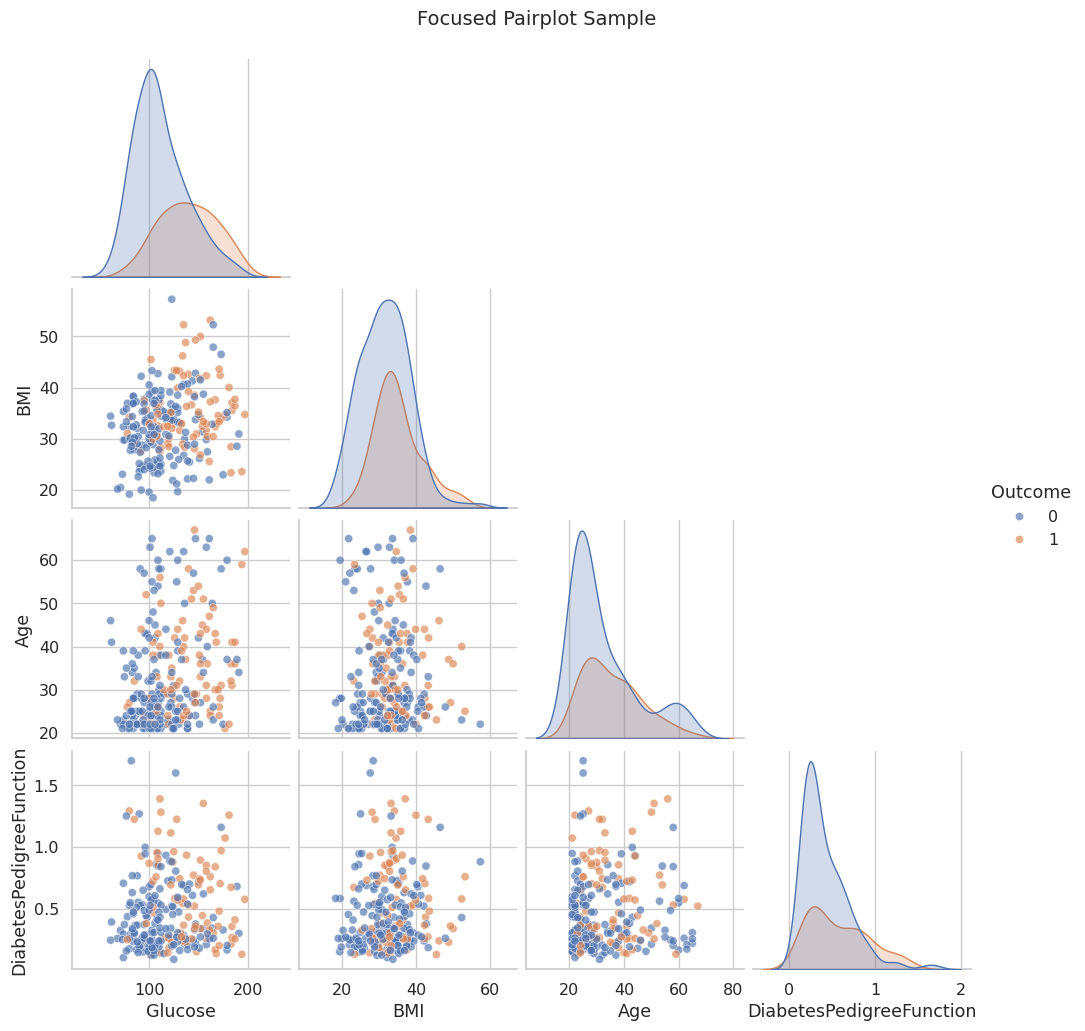

In [15]:
pairplot_features = ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction", "Outcome"]
pairplot_sample = df_vis[pairplot_features].sample(
    n=min(250, len(df_vis)),
    random_state=RANDOM_SEED,
)

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="The figure layout has changed to tight",
        category=UserWarning,
    )

    pair_grid = sns.pairplot(
        pairplot_sample,
        hue="Outcome",
        diag_kind="kde",
        corner=True,
        plot_kws={"alpha": 0.65, "s": 35},
    )

pair_grid.fig.suptitle("Focused Pairplot Sample", fontsize=14, y=1.03)
plt.show()

### Pairplot suggests that positive cases are more frequent around higher Glucose and BMI values.


## Glucose vs BMI colored by Outcome

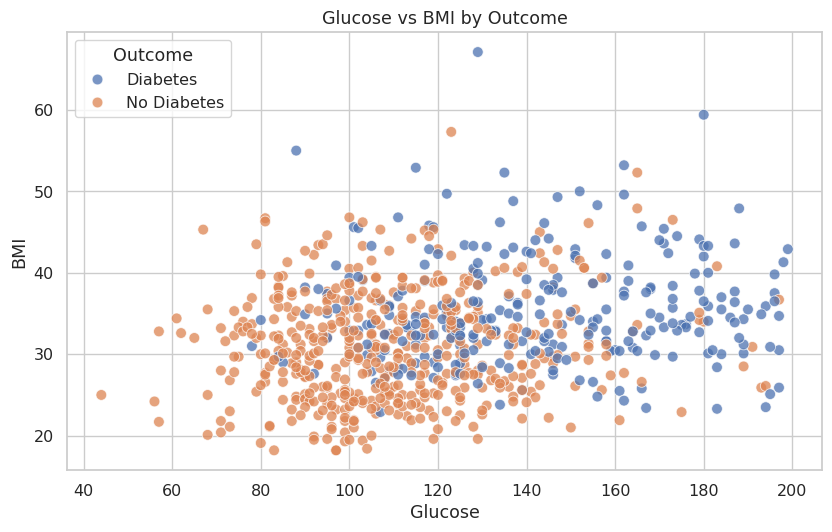

In [16]:
plt.figure(figsize=(8.5, 5.5))
sns.scatterplot(
    data=df_vis,
    x="Glucose",
    y="BMI",
    hue=df_vis["Outcome"].map({0: "No Diabetes", 1: "Diabetes"}),
    alpha=0.75,
    s=60,
)
plt.title("Glucose vs BMI by Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

### The scatter suggests a visible concentration of positive cases among higher Glucose and BMI values.


## Correlation matrix

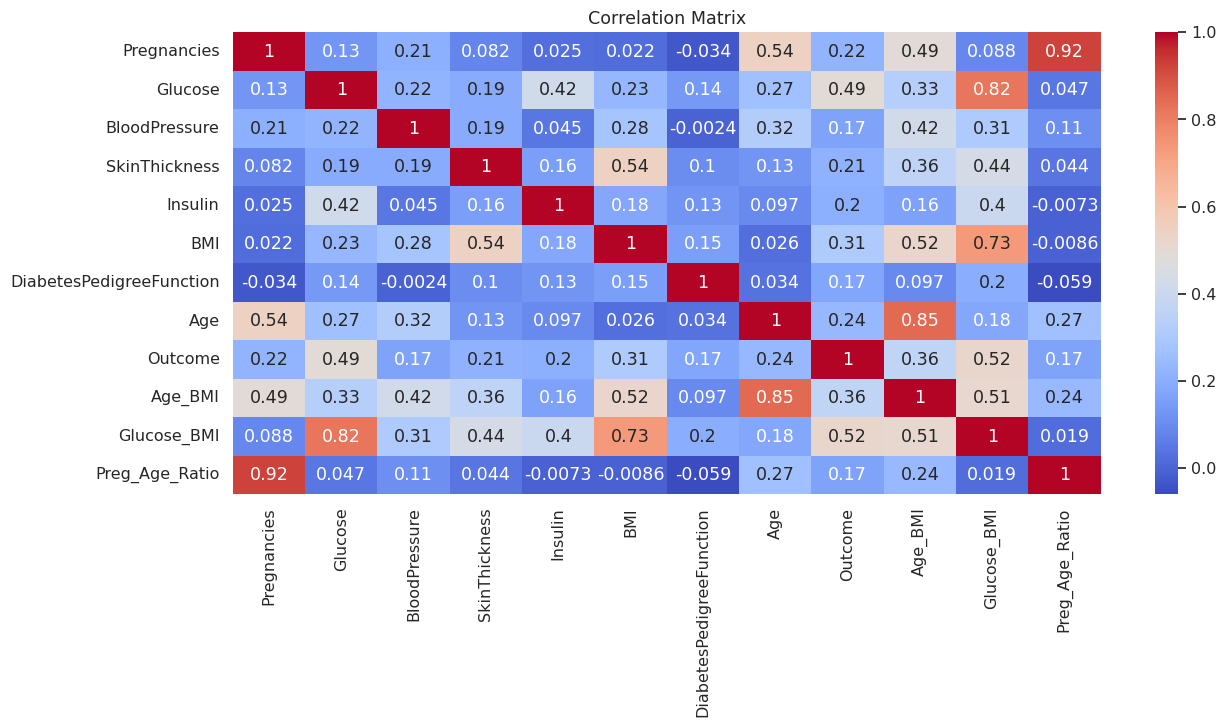

In [17]:
plt.figure(figsize=(14,6))
sns.heatmap(df_vis.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

### Glucose is one of the strongest positive signals associated with diabetes outcome.

## Features Distribution by Class

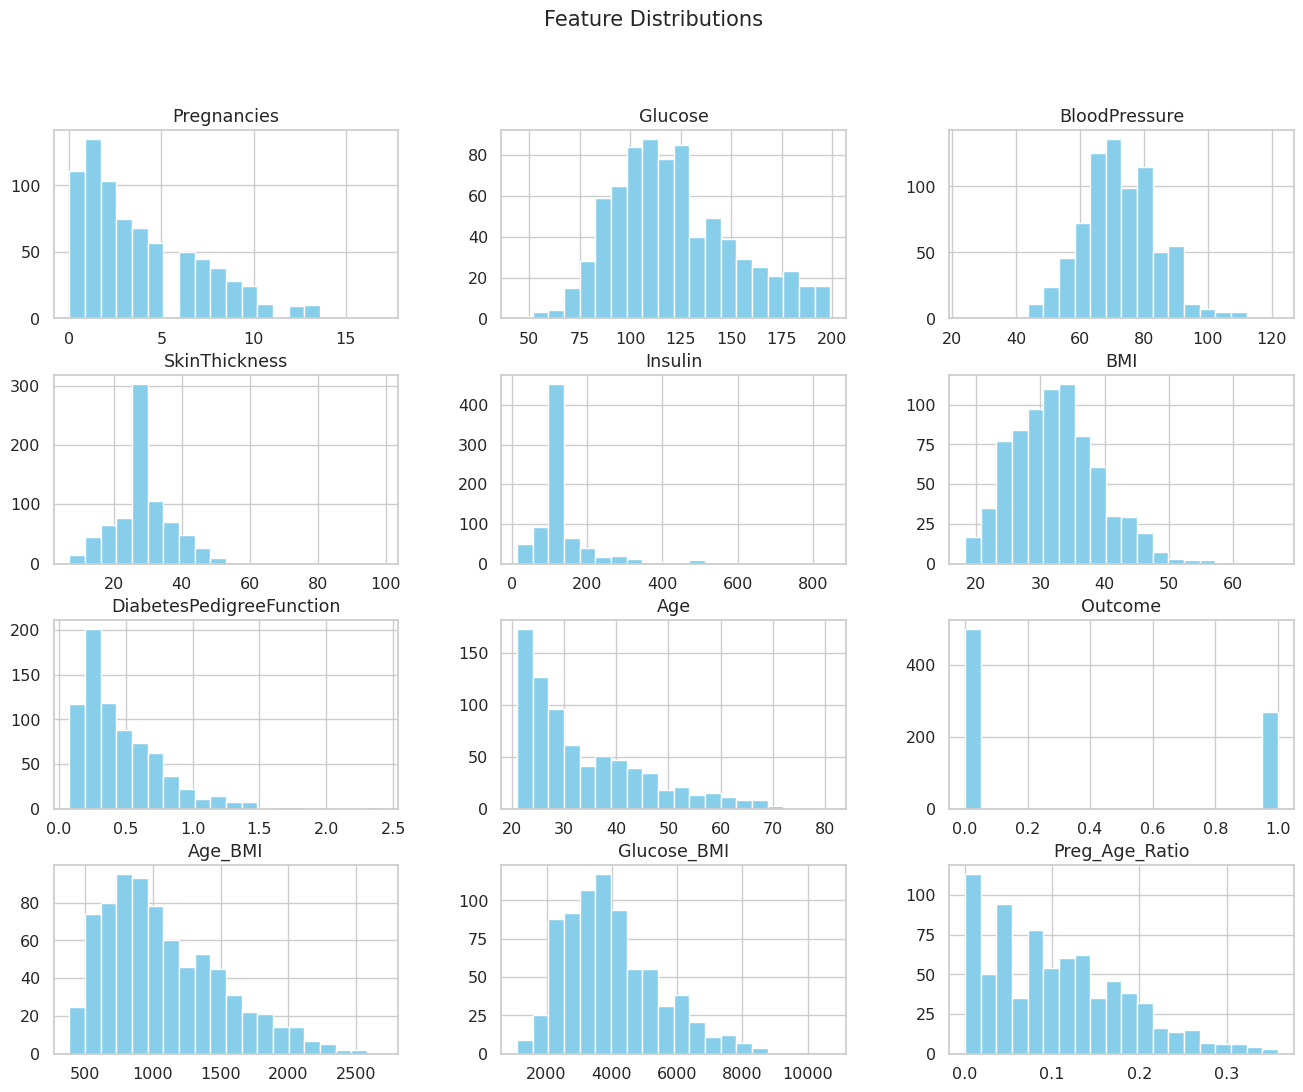

In [18]:
df_vis.hist(bins=20, figsize=(16,12), color='skyblue')
plt.suptitle('Feature Distributions')
plt.show()

### Diabetes-positive cases tend to show higher Glucose, BMI, and Age values in this dataset.


## Boxplots for Key Features


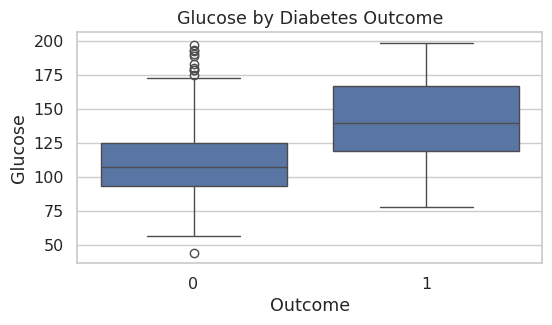

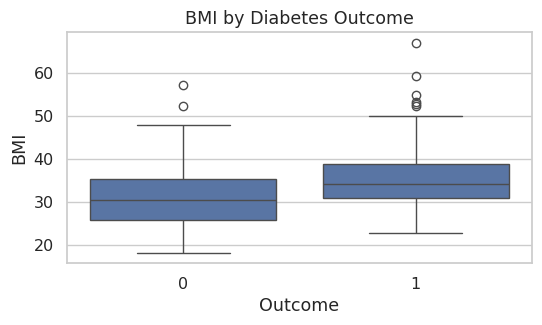

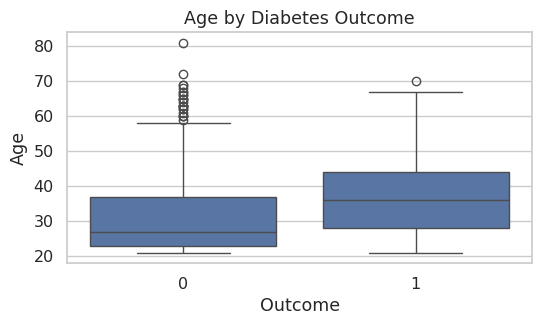

In [19]:
for col in ['Glucose','BMI','Age']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='Outcome', y=col, data=df_vis)
    plt.title(f'{col} by Diabetes Outcome')
    plt.show()

### Boxplots show higher central values for Glucose, BMI, and Age among diabetes-positive cases.


## Grouped Insights

## Diabetes Rate by Age Group

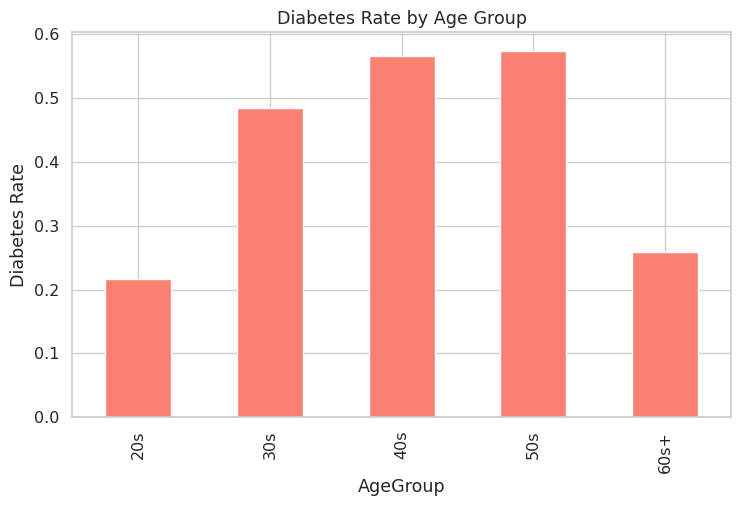

In [20]:
age_diabetes = df_vis.groupby('AgeGroup')['Outcome'].mean()
age_diabetes.plot(kind='bar', color='salmon')
plt.title('Diabetes Rate by Age Group')
plt.ylabel('Diabetes Rate')
plt.show()

### Observed diabetes-positive rates are higher in older age groups, especially when BMI is also elevated.

## BMI Distribution by Outcome

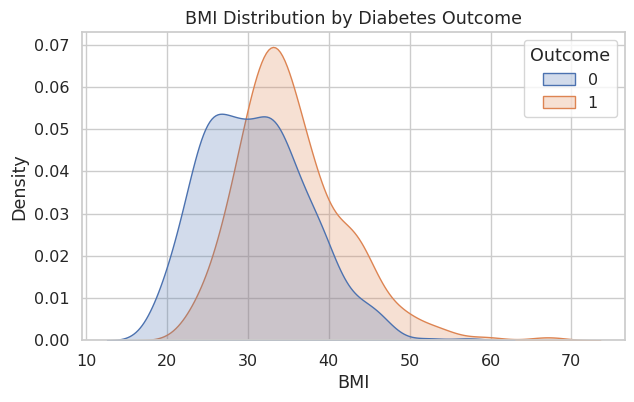

In [21]:
plt.figure(figsize=(7,4))
sns.kdeplot(data=df_vis, x="BMI", hue="Outcome", fill=True, common_norm=False)
plt.title('BMI Distribution by Diabetes Outcome')
plt.show()

### Higher BMI groups show higher observed diabetes-positive rates in this dataset.

## Split Strategy

We use three data partitions:

- **Inner train**: model fitting, cross-validation, and hyperparameter tuning.
- **Validation**: threshold selection only.
- **Test**: final one-time evaluation only.

This prevents the operating threshold from being selected on data the final model has already seen.

In [22]:
X = df[BASE_FEATURES].copy()
y = df["Outcome"].astype(int).copy()

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y,
)

X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_dev,
)

XGB_SCALE_POS_WEIGHT = (y_train_inner == 0).sum() / max((y_train_inner == 1).sum(), 1)

split_summary = pd.DataFrame(
    [
        ["inner_train", len(y_train_inner), positive_rate(y_train_inner)],
        ["validation", len(y_val), positive_rate(y_val)],
        ["test", len(y_test), positive_rate(y_test)],
    ],
    columns=["split", "rows", "positive_rate"],
)

display(split_summary)


def apply_fallback_balance(clf):
    """Apply estimator-side imbalance handling when SMOTE is unavailable."""
    clf = clone(clf)
    params = clf.get_params()

    if "class_weight" in params and params.get("class_weight") is None:
        class_weight = "balanced_subsample" if isinstance(clf, RandomForestClassifier) else "balanced"
        clf.set_params(class_weight=class_weight)

    if "scale_pos_weight" in params and params.get("scale_pos_weight") in (None, 1):
        clf.set_params(scale_pos_weight=XGB_SCALE_POS_WEIGHT)

    return clf


def make_pipeline(clf, use_smote=True):
    steps = [
        ("zero_nan", FunctionTransformer(zeros_to_nan, validate=False)),
        ("add_feat", FunctionTransformer(add_interactions, validate=False)),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]

    if use_smote and USE_IMBLEARN_SMOTE:
        steps.append(("smote", SMOTE(random_state=RANDOM_SEED, k_neighbors=5)))
    elif use_smote:
        clf = apply_fallback_balance(clf)

    steps.append(("clf", clf))

    pipeline_cls = ImbPipeline if USE_IMBLEARN_SMOTE else SafeSklearnPipeline
    return pipeline_cls(steps=steps)


models = {
    "Dummy (Most Frequent)": make_pipeline(
        DummyClassifier(strategy="most_frequent"),
        use_smote=False,
    ),
    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=3000, solver="saga", random_state=RANDOM_SEED),
        use_smote=True,
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=400,
            n_jobs=-1,
            random_state=RANDOM_SEED,
        ),
        use_smote=True,
    ),
}

if HAS_XGB:
    models["XGBoost"] = make_pipeline(
        XGBClassifier(
            random_state=RANDOM_SEED,
            eval_metric="logloss",
            tree_method="hist",
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_lambda=1.0,
        ),
        use_smote=True,
    )

print("Models:", ", ".join(models.keys()))


,split,rows,positive_rate
0,inner_train,491,0.348269
1,validation,123,0.349593
2,test,154,0.350649


Models: Dummy (Most Frequent), Logistic Regression, Random Forest


# Baseline via 5-Fold Out-of-Fold Predictions

This reference baseline estimates performance on the inner-training split only, without using validation or final test rows.

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

baseline_pipe = make_pipeline(
    LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_SEED,
    ),
    use_smote=False,
)

oof_proba = np.zeros(len(y_train_inner))

for train_idx, valid_idx in skf.split(X_train_inner, y_train_inner):
    model = clone(baseline_pipe)
    model.fit(X_train_inner.iloc[train_idx], y_train_inner.iloc[train_idx])
    oof_proba[valid_idx] = model.predict_proba(X_train_inner.iloc[valid_idx])[:, 1]

baseline_oof = {
    "oof_roc_auc": roc_auc_score(y_train_inner, oof_proba),
    "oof_pr_auc": average_precision_score(y_train_inner, oof_proba),
    "oof_brier": brier_score_loss(y_train_inner, oof_proba),
}

display(pd.Series(baseline_oof).round(4).to_frame("score"))

,score
oof_roc_auc,0.8315
oof_pr_auc,0.7017
oof_brier,0.1673


## Cross-Validation on Inner Train

Model comparison is done only on `X_train_inner`.  
The validation split remains untouched until threshold selection.

In [24]:
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": "recall",
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "auprc": "average_precision",
    "brier_neg": "neg_brier_score",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

results = []
best_estimators = {}

for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X_train_inner,
        y_train_inner,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_estimator=True,
        error_score="raise",
    )

    row = {metric: scores[f"test_{metric}"].mean() for metric in scoring}
    row.update({f"{metric}_std": scores[f"test_{metric}"].std() for metric in scoring})
    row["Model"] = name
    results.append(row)

    best_idx = int(np.argmax(scores["test_f1"]))
    best_estimators[name] = scores["estimator"][best_idx]

cv_df = pd.DataFrame(results).set_index("Model").sort_values("f1", ascending=False)

display(cv_df.round(3))

best_name = cv_df["f1"].idxmax()
best_pipe = best_estimators[best_name]

print(f"Best untuned model by inner-CV F1: {best_name}")

,accuracy,precision,recall,f1,roc_auc,auprc,brier_neg,accuracy_std,precision_std,recall_std,f1_std,roc_auc_std,auprc_std,brier_neg_std
Model,,,,,,,,,,,,,,
Logistic Regression,0.754,0.634,0.696,0.662,0.840,0.732,-0.167,0.027,0.033,0.077,0.043,0.038,0.062,0.026
Random Forest,0.766,0.710,0.591,0.638,0.827,0.698,-0.164,0.038,0.108,0.058,0.043,0.040,0.070,0.020
Dummy (Most Frequent),0.652,0.000,0.000,0.000,0.500,0.348,-0.348,0.003,0.000,0.000,0.000,0.000,0.003,0.003


Best untuned model by inner-CV F1: Logistic Regression


# Threshold Selection Helpers

The operating threshold is selected on validation data only.  
Two useful thresholds are reported:

- **F1-optimal threshold**
- **Cost-optimal threshold**, using the illustrative false-positive and false-negative costs defined earlier

In [25]:
def choose_thresholds(y_true, proba, cost_fp=COST_FP, cost_fn=COST_FN):
    precision, recall, pr_thresholds = precision_recall_curve(y_true, proba)

    # precision/recall arrays have one extra point compared with thresholds.
    f1_values = 2 * (precision[:-1] * recall[:-1]) / (
        precision[:-1] + recall[:-1] + 1e-12
    )

    if len(pr_thresholds):
        thr_f1 = float(pr_thresholds[int(np.argmax(f1_values))])
    else:
        thr_f1 = 0.50

    threshold_grid = np.linspace(0.05, 0.95, 37)
    costs = [
        expected_cost(y_true, proba, threshold, cost_fp=cost_fp, cost_fn=cost_fn)
        for threshold in threshold_grid
    ]
    thr_cost = float(threshold_grid[int(np.argmin(costs))])

    threshold_summary = pd.DataFrame(
        [
            ["f1_optimal", thr_f1, expected_cost(y_true, proba, thr_f1, cost_fp, cost_fn)],
            ["cost_optimal", thr_cost, min(costs)],
        ],
        columns=["strategy", "threshold", "validation_cost"],
    )

    return threshold_summary

# Hyperparameter Tuning and Final Model Selection

Candidate models are tuned on the inner-training split only.  
The final calibrated model is then fitted on the inner-training split and evaluated against validation for threshold selection.

In [26]:
search_jobs = []

param_lr = {
    "clf__C": np.logspace(-3, 2, 12),
    "clf__penalty": ["l1", "l2"],
}

search_jobs.append(
    (
        "Logistic Regression (tuned)",
        RandomizedSearchCV(
            estimator=make_pipeline(
                LogisticRegression(
                    max_iter=3000,
                    solver="saga",
                    random_state=RANDOM_SEED,
                ),
                use_smote=True,
            ),
            param_distributions=param_lr,
            n_iter=12,
            scoring="f1",
            cv=cv,
            n_jobs=-1,
            random_state=RANDOM_SEED,
            verbose=0,
        ),
    )
)

param_rf = {
    "clf__n_estimators": [300, 500, 800],
    "clf__max_depth": [None, 4, 6, 10],
    "clf__min_samples_split": [2, 4, 6],
    "clf__min_samples_leaf": [1, 2, 3],
    "clf__max_features": ["sqrt", "log2", None],
}

search_jobs.append(
    (
        "Random Forest (tuned)",
        RandomizedSearchCV(
            estimator=make_pipeline(
                RandomForestClassifier(n_jobs=-1, random_state=RANDOM_SEED),
                use_smote=True,
            ),
            param_distributions=param_rf,
            n_iter=12,
            scoring="f1",
            cv=cv,
            n_jobs=-1,
            random_state=RANDOM_SEED,
            verbose=0,
        ),
    )
)

if HAS_XGB:
    param_xgb = {
        "clf__n_estimators": [150, 250, 400],
        "clf__max_depth": [2, 3, 4],
        "clf__learning_rate": [0.03, 0.05, 0.08, 0.10],
        "clf__subsample": [0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.8, 0.9, 1.0],
        "clf__reg_lambda": [0.5, 1.0, 2.0],
    }

    search_jobs.append(
        (
            "XGBoost (tuned)",
            RandomizedSearchCV(
                estimator=make_pipeline(
                    XGBClassifier(
                        random_state=RANDOM_SEED,
                        eval_metric="logloss",
                        tree_method="hist",
                    ),
                    use_smote=True,
                ),
                param_distributions=param_xgb,
                n_iter=8,
                scoring="f1",
                cv=cv,
                n_jobs=-1,
                random_state=RANDOM_SEED,
                verbose=0,
            ),
        )
    )

tuning_rows = []
search_objects = {}

for model_name, search in search_jobs:
    search.fit(X_train_inner, y_train_inner)
    search_objects[model_name] = search
    tuning_rows.append(
        {
            "model": model_name,
            "best_cv_f1": search.best_score_,
            "best_params": search.best_params_,
        }
    )

tuning_df = pd.DataFrame(tuning_rows).sort_values("best_cv_f1", ascending=False)
display(tuning_df[["model", "best_cv_f1"]].round(4))

final_name = tuning_df.iloc[0]["model"]
final_pipe = search_objects[final_name].best_estimator_

final_calibrated = make_calibrated(
    estimator=final_pipe,
    method=CALIBRATION_METHOD,
    cv=5,
)

final_calibrated.fit(X_train_inner, y_train_inner)

val_proba_cal_final = final_calibrated.predict_proba(X_val)[:, 1]
threshold_summary = choose_thresholds(y_val, val_proba_cal_final)

display(threshold_summary.round(4))

oper_thr_final = float(
    threshold_summary.loc[
        threshold_summary["strategy"].eq("cost_optimal"),
        "threshold",
    ].iloc[0]
)

print(f"Final model: {final_name}")
print(f"Calibration: {CALIBRATION_METHOD}")
print(f"Operating threshold selected on validation only: {oper_thr_final:.3f}")

,model,best_cv_f1
1,Random Forest (tuned),0.6950
0,Logistic Regression (tuned),0.6703


,strategy,threshold,validation_cost
0,f1_optimal,0.2852,59.0
1,cost_optimal,0.1250,48.0


Final model: Random Forest (tuned)
Calibration: sigmoid
Operating threshold selected on validation only: 0.125


## Final Evaluation on the Held-Out Test Set

The test set is used once here for final reporting.  
No model or threshold decision is changed after this point.

,threshold,accuracy,precision,recall,f1,roc_auc,auprc,brier,tn,fp,fn,tp
strategy,,,,,,,,,,,,
default_0.50,0.500,0.7208,0.6222,0.5185,0.5657,0.8194,0.6966,0.1662,83,17,26,28
validation_cost_optimal,0.125,0.6039,0.4679,0.9444,0.6258,0.8194,0.6966,0.1662,42,58,3,51


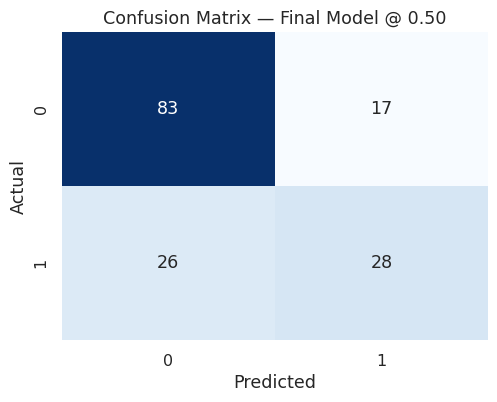

              precision    recall  f1-score   support

           0      0.761     0.830     0.794       100
           1      0.622     0.519     0.566        54

    accuracy                          0.721       154
   macro avg      0.692     0.674     0.680       154
weighted avg      0.713     0.721     0.714       154



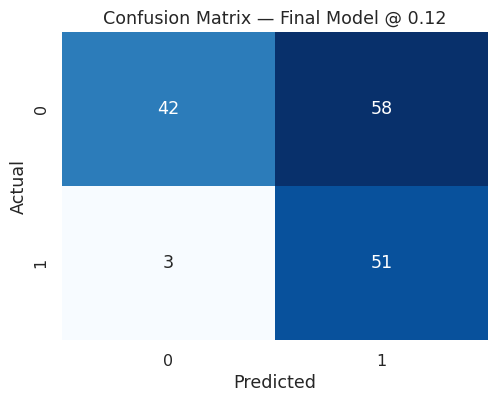

              precision    recall  f1-score   support

           0      0.933     0.420     0.579       100
           1      0.468     0.944     0.626        54

    accuracy                          0.604       154
   macro avg      0.701     0.682     0.603       154
weighted avg      0.770     0.604     0.596       154



In [27]:
def metrics_at_threshold(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, proba),
        "auprc": average_precision_score(y_true, proba),
        "brier": brier_score_loss(y_true, proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def plot_confusion_matrix(y_true, proba, threshold, title):
    y_pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print(classification_report(y_true, y_pred, digits=3, zero_division=0))


test_proba_cal_final = final_calibrated.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame(
    [
        {"strategy": "default_0.50", **metrics_at_threshold(y_test, test_proba_cal_final, 0.50)},
        {
            "strategy": "validation_cost_optimal",
            **metrics_at_threshold(y_test, test_proba_cal_final, oper_thr_final),
        },
    ]
).set_index("strategy")

display(test_metrics.round(4))

plot_confusion_matrix(
    y_test,
    test_proba_cal_final,
    0.50,
    "Confusion Matrix — Final Model @ 0.50",
)

plot_confusion_matrix(
    y_test,
    test_proba_cal_final,
    oper_thr_final,
    f"Confusion Matrix — Final Model @ {oper_thr_final:.2f}",
)

# Reliability Diagram on Test

Calibration is inspected after the final test predictions are produced.

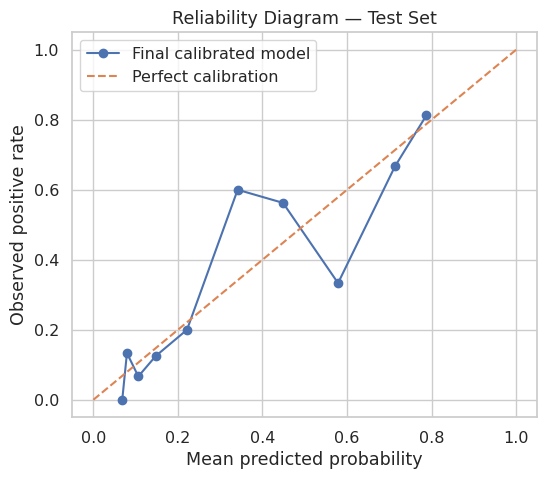

In [28]:
prob_true, prob_pred = calibration_curve(
    y_test,
    test_proba_cal_final,
    n_bins=10,
    strategy="quantile",
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Final calibrated model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed positive rate")
plt.title("Reliability Diagram — Test Set")
plt.legend()
plt.show()

# Model Comparison Curves on Test

These plots are used for final model inspection only.  
The final model and operating threshold were already selected before looking at the test set.

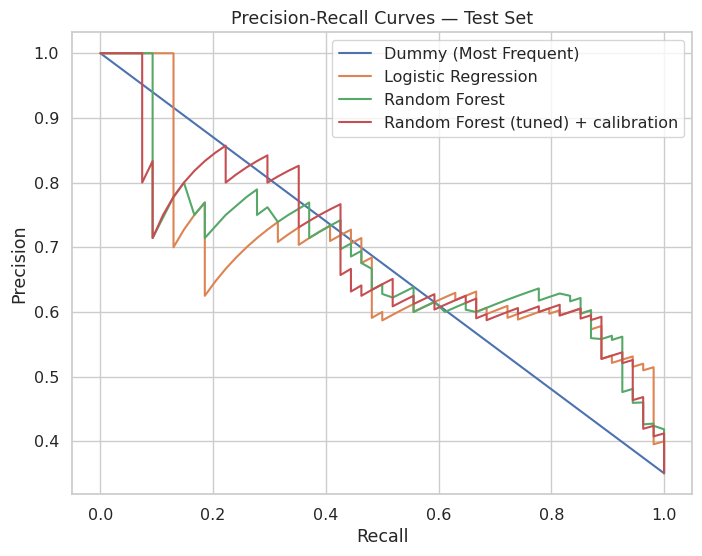

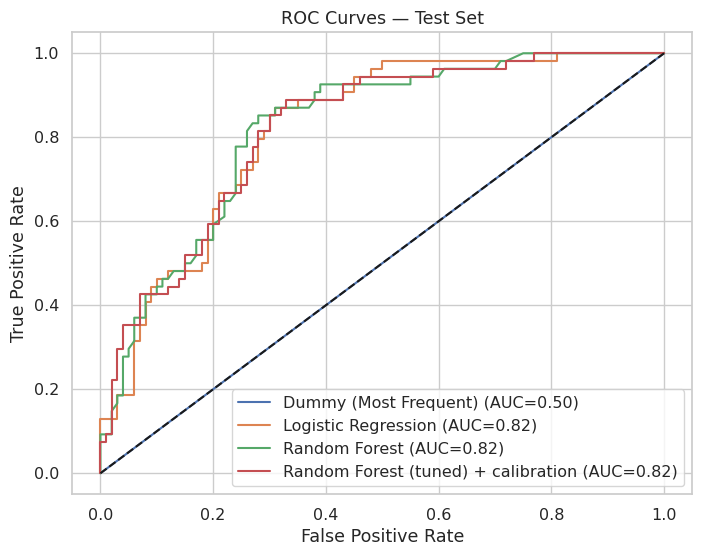

In [29]:
y_probas = {}

for name, pipe in models.items():
    model = clone(pipe)
    model.fit(X_train_inner, y_train_inner)
    y_probas[name] = model.predict_proba(X_test)[:, 1]

y_probas[f"{final_name} + calibration"] = test_proba_cal_final

plt.figure(figsize=(8, 6))
for name, proba in y_probas.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Test Set")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
for name, proba in y_probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.show()

# Permutation Importance

Permutation importance is computed on the held-out test set using AUPRC as the scoring metric.

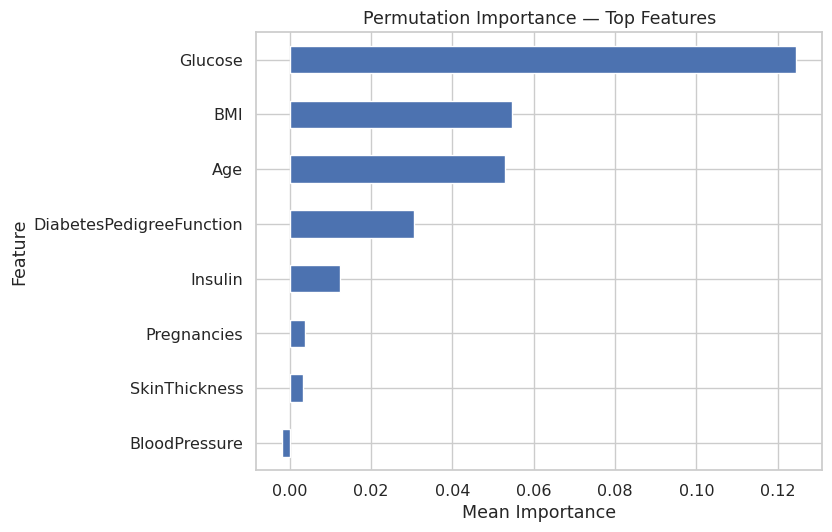

,mean_importance
Glucose,0.1246
BMI,0.0548
Age,0.0530
DiabetesPedigreeFunction,0.0306
Insulin,0.0123
Pregnancies,0.0038
SkinThickness,0.0034
BloodPressure,-0.0019


In [30]:
r = permutation_importance(
    final_calibrated,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    scoring="average_precision",
)

pi = pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8.5, 5.5))
pi.head(12).sort_values().plot(kind="barh")
plt.title("Permutation Importance — Top Features")
plt.xlabel("Mean Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(pi.head(10).round(4).to_frame("mean_importance"))

# Learning Curve

The learning curve uses average precision because this is an imbalanced binary-classification problem.

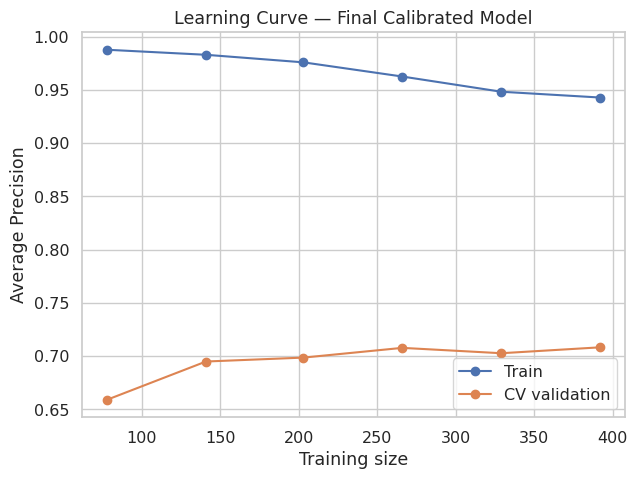

In [31]:
train_sizes, train_scores, val_scores = learning_curve(
    final_calibrated,
    X_train_inner,
    y_train_inner,
    cv=5,
    scoring="average_precision",
    n_jobs=1,
    train_sizes=np.linspace(0.2, 1.0, 6),
    shuffle=True,
    random_state=RANDOM_SEED,
)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Train")
plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="CV validation")
plt.xlabel("Training size")
plt.ylabel("Average Precision")
plt.title("Learning Curve — Final Calibrated Model")
plt.legend()
plt.show()

# Save Artifacts

The saved artifact contains the fitted calibrated pipeline, feature list, selected threshold, cost assumptions, and evaluation summaries.

In [32]:
SAVE_ARTIFACTS = True
ARTIFACTS_DIR = Path("./artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

bundle = {
    "pipeline": final_calibrated,
    "features": BASE_FEATURES,
    "cv_summary": cv_df.round(4).to_dict(),
    "tuning_summary": tuning_df[["model", "best_cv_f1"]].round(4).to_dict(orient="records"),
    "best_model_name": final_name,
    "calibration": CALIBRATION_METHOD,
    "operating_threshold": float(oper_thr_final),
    "validation_threshold_summary": threshold_summary.round(4).to_dict(orient="records"),
    "test_metrics": test_metrics.round(4).to_dict(orient="index"),
    "cost_fp": float(COST_FP),
    "cost_fn": float(COST_FN),
    "random_seed": int(RANDOM_SEED),
    "protocol": (
        "Fit/tune/calibrate on inner train, select operating threshold on validation, "
        "evaluate once on held-out test."
    ),
    "benchmark_note": "Benchmark ML artifact for reproducible modeling, calibration, and threshold analysis.",
}

if SAVE_ARTIFACTS:
    artifact_path = ARTIFACTS_DIR / "pima_best_pipeline.joblib"
    joblib.dump(bundle, artifact_path)
    print(f"Saved artifact: {artifact_path} | operating_threshold={oper_thr_final:.3f}")

Saved artifact: artifacts/pima_best_pipeline.joblib | operating_threshold=0.125


In [33]:
operating_metrics = test_metrics.loc["validation_cost_optimal"]
top_features = ", ".join(pi.head(3).index.tolist())

display(
    Markdown(
        f"""
## Final Summary

The final model is **{final_name}** with **{CALIBRATION_METHOD} calibration**.

The operating threshold was selected on the validation split only using an illustrative cost policy:

- False positive cost: **{COST_FP:g}**
- False negative cost: **{COST_FN:g}**
- Selected threshold: **{oper_thr_final:.3f}**

On the held-out test set, this validation-selected threshold produced:

| Metric | Value |
|---|---:|
| Accuracy | {operating_metrics["accuracy"]:.3f} |
| Precision | {operating_metrics["precision"]:.3f} |
| Recall | {operating_metrics["recall"]:.3f} |
| F1 | {operating_metrics["f1"]:.3f} |
| ROC-AUC | {operating_metrics["roc_auc"]:.3f} |
| AUPRC | {operating_metrics["auprc"]:.3f} |
| Brier score | {operating_metrics["brier"]:.3f} |

### Interpretation

The selected threshold favors recall because false negatives were assigned a higher policy cost in this workflow.
This creates a more conservative screening-style setting: fewer missed positive cases, with more false positives as the tradeoff.

The strongest input-level model signals in this run were: **{top_features}**.

### Practical Notes

- The cost values are configurable and should be aligned with the intended decision policy.
- This benchmark workflow is not a clinical recommendation.
- Real-world use would require external validation, governance review, and monitoring for calibration and population drift.
"""
    )
)


## Final Summary

The final model is **Random Forest (tuned)** with **sigmoid calibration**.

The operating threshold was selected on the validation split only using an illustrative cost policy:

- False positive cost: **1**
- False negative cost: **7**
- Selected threshold: **0.125**

On the held-out test set, this validation-selected threshold produced:

| Metric | Value |
|---|---:|
| Accuracy | 0.604 |
| Precision | 0.468 |
| Recall | 0.944 |
| F1 | 0.626 |
| ROC-AUC | 0.819 |
| AUPRC | 0.697 |
| Brier score | 0.166 |

### Interpretation

The selected threshold favors recall because false negatives were assigned a higher policy cost in this workflow.
This creates a more conservative screening-style setting: fewer missed positive cases, with more false positives as the tradeoff.

The strongest input-level model signals in this run were: **Glucose, BMI, Age**.

### Practical Notes

- The cost values are configurable and should be aligned with the intended decision policy.
- This benchmark workflow is not a clinical recommendation.
- Real-world use would require external validation, governance review, and monitoring for calibration and population drift.
